# The lift test and calibration

> Alderquist is a fictional direct to consumer home goods brand and its market is simulated with known truth. The email experiment is Kevin Hillstrom's public 2008 dataset, the purchase history is the UCI Online Retail II dataset, and the large uplift set is Criteo's public research release. No real company's spend and no real customer's identity appears here.

In this notebook I design a geo lift test on the demonstration market, register its plan, run it, check it, analyse it two ways, keep one dead end from the build, measure power by simulation, and feed the result into the mix model.

Every number printed below comes from this notebook's run and says how many seeds it rests on. None of them is copied into a document. Where I show a published figure, I read it from `results/manifest.json` and print its provenance beside it. The notebook needs only the committed files under `results`; it simulates everything else and never opens `data/external`.

In [1]:
import json
import textwrap
import time

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import polars as pl
from marginal_core.config import CHANNEL_LABELS, CHANNELS, POLICY
from marginal_core.formats import format_value
from marginal_core.manifest import Manifest
from marginal_core.paths import paths
from marginal_core.statements import contains_statement

ROOT = paths().root
NOTEBOOK = ROOT / "notebooks" / "02_lift_test_and_calibration.ipynb"
# The statement in the first cell must match the one the code carries, word for word.
assert contains_statement(nbformat.read(NOTEBOOK, as_version=4).cells[0].source)

manifest = Manifest.load(paths().manifest)
SEED = manifest.seed  # the seed behind every published figure on the demonstration brand

# The site's palette in light mode. Channels take the categorical slots in their fixed order and
# slot eight is kept for comparators, as on the site.
PALETTE = json.loads((ROOT / "web" / "src" / "theme" / "palette.json").read_text())["light"]
INK, INK2, CONTROL, HAIRLINE, RAISED = (PALETTE[k] for k in ("ink", "ink2", "control", "hairline", "raised"))
CAT, SEQ = PALETTE["categorical"], PALETTE["sequential"]
COLOR = {channel: CAT[i] for i, channel in enumerate(CHANNELS)}
COMPARATOR = CAT[7]

plt.rcParams.update(
    {
        "figure.facecolor": RAISED,
        "axes.facecolor": RAISED,
        "savefig.facecolor": RAISED,
        "figure.dpi": 100,
        "axes.edgecolor": HAIRLINE,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 10,
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": HAIRLINE,
        "grid.linewidth": 0.8,
        "xtick.color": HAIRLINE,
        "ytick.color": HAIRLINE,
        "xtick.labelcolor": INK2,
        "ytick.labelcolor": INK2,
        "text.color": INK,
        "text.parse_math": False,  # dollar signs in labels are dollars
        "font.size": 9,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
    }
)


def run(seeds, detail=""):
    """The label on every number this notebook computes."""
    return f"This notebook's run, {seeds} seed{'' if seeds == 1 else 's'}{detail}."


def published(key):
    """A published figure as the manifest formats it, with its provenance."""
    return f"{manifest.text(key)}  [{manifest.label(key)}]"


def show(columns, rows, note):
    """A small table as aligned text, the first column to the left and the rest to the right,
    with the line that says whose numbers these are."""
    cells = [[str(c) for c in columns], *[[str(v) for v in row] for row in rows]]
    widths = [max(len(row[i]) for row in cells) for i in range(len(columns))]

    def line(row):
        return "  ".join(v.ljust(w) if i == 0 else v.rjust(w) for i, (v, w) in enumerate(zip(row, widths)))

    print("\n".join([line(cells[0]), "  ".join("-" * w for w in widths), *map(line, cells[1:]), note]))


def finish(fig, title, note):
    """The title at the top left and the provenance line under the chart, wrapped to the figure's width."""
    fig.suptitle(title, x=0.01, ha="left", fontsize=11.5, color=INK)
    fig.text(0.01, -0.01, textwrap.fill(note, width=int(fig.get_figwidth() * 15)), ha="left", va="top", fontsize=8, color=INK2)
    plt.show()


def usd(value):
    return format_value(value, "usd0")

## 1. Why the experiment sits upstream of the budget

The mix model learns from a panel where spend follows plans and demand. It can fit that panel well and still be wrong about a channel, and the recovery study says where: display and retargeting, whose spend rises after good weeks, is the channel the model credits with demand it did not cause. More modelling on the same panel cannot fix that, because the confusion is in the data. A geo lift test is the one place in the build where the cause is set by hand: switch the channel off in some geos for eight weeks and see what their sales do. So the experiment comes first. Its result constrains the model, the calibrated model draws the response curves, and only then does the optimizer move money. This notebook follows the order a measurement team works in: design, register, run, check, analyse, then calibrate.

## 2. Designing the test

`design_test` sorts the geos by their sales over the 52 weeks before the window, cuts them into strata of four and draws one treated geo from each, so the treated group spans the size distribution. The channel, the spend change and the window come from the stated policy: display and retargeting, spend to zero in the treated geos, the last eight weeks of the panel. The design is fixed before the test's data exists.

In [2]:
from marginal_experiments import design_test
from marginal_sim import demonstration_spec, simulate_market

base = demonstration_spec(SEED)
geo_before, _, _ = simulate_market(base)
design = design_test(geo_before, seed=SEED)

pre = geo_before.filter(pl.col("week").is_between(design.start_week - design.pre_period_weeks, design.start_week - 1))
by_size = pre.group_by("geo").agg(pl.col("sales").sum()).sort(["sales", "geo"])["geo"].to_list()
size_rank = {geo: i + 1 for i, geo in enumerate(by_size)}
print(f"Channel: {CHANNEL_LABELS[design.channel]}, spend change {design.spend_change:+.0%} in the treated geos.")
print(f"Window: weeks {design.start_week} to {design.end_week} ({design.window_weeks} weeks), after a pre period of {design.pre_period_weeks} weeks.")
print(f"Treated geos: {', '.join(map(str, design.treated_geos))}; {len(design.control_geos)} control geos.")
print(f"Their ranks by pre period sales, 1 the smallest of {base.geos}: {', '.join(map(str, sorted(size_rank[g] for g in design.treated_geos)))}.")
print(f"Analysis: {design.analysis}; {design.placebo_permutations} placebo permutations; {design.interval_level:.0%} intervals.")
print(run(1, f" (seed {SEED})"))

Channel: Display and retargeting, spend change -100% in the treated geos.
Window: weeks 148 to 155 (8 weeks), after a pre period of 52 weeks.
Treated geos: 5, 8, 9, 11, 16, 19, 20, 21, 34, 35; 30 control geos.
Their ranks by pre period sales, 1 the smallest of 40: 1, 5, 9, 15, 18, 23, 26, 30, 33, 37.
Analysis: difference in differences with geo and week fixed effects on log sales; synthetic control with placebo inference; 200 placebo permutations; 90% intervals.
This notebook's run, 1 seed (seed 12).


The plan hash is how the build keeps itself honest. It is sixteen hex characters of the SHA-256 of the design's canonical JSON, registered before the test's data is generated, and a result can only be posted against it. Change anything in the design and the hash changes, so a design quietly edited after the data came in cannot pass for the one that was registered. The pipeline ran its power study before registering and wrote the power at the true effect into the plan, so the plan it registered carries one more field than `design_test` returns. Filling that field in with the value the manifest records should give the registered hash exactly.

In [3]:
registered_power = manifest.raw("geo.power_at_true_effect")
variants = [
    ("as designed", design),
    ("the window one week shorter", design.model_copy(update={"start_week": design.start_week + 1})),
    ("half the spend cut instead of all of it", design.model_copy(update={"spend_change": -0.5})),
    ("the geos drawn with another seed", design_test(geo_before, seed=SEED + 1)),
    ("the power at the true effect filled in", design.model_copy(update={"power_at_true_effect": registered_power})),
]
show(["Design", "Plan hash"], [[name, d.plan_hash] for name, d in variants], run(1, f" (seed {SEED})"))
print()
print("The pipeline registered:", published("geo.plan_hash"))
print("The power it wrote into the plan:", published("geo.power_at_true_effect"))
registered = variants[-1][1]
print("The last variant is the registered plan:", registered.plan_hash == manifest.raw("geo.plan_hash"))

Design                                          Plan hash
---------------------------------------  ----------------
as designed                              0a2615faffee27cf
the window one week shorter              48ea9e44e1c7b708
half the spend cut instead of all of it  ab5f98c0e803c955
the geos drawn with another seed         6a7f12fb1944c58f
the power at the true effect filled in   53733a76fe1af6ec
This notebook's run, 1 seed (seed 12).

The pipeline registered: 53733a76fe1af6ec  [Source: simulated, model did, 10 treated geos of 40, 8 weeks, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
The power it wrote into the plan: 100%  [Source: simulated, model did, 10 treated geos of 40, 8 weeks, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
The last variant is the registered plan: True


From here on I use the registered plan. The sample ratio mismatch gate is part of the design too: no result is shown while the assignment the data shows is unlikely under the planned ratio. It runs in the next section, once the test's data exists, before any estimate.

## 3. Running and analysing the test

Only now does the test's data exist. I simulate the same market with display and retargeting switched off in the treated geos for the window. Everything else about the market, its noise included, is unchanged, which is also what lets the simulator say exactly what the test removed. Before any estimate, the SRM gate: I count the geos the data shows with no display and retargeting spend through the window and test that count against the plan's ten of forty. On forty geos the gate has little power against a small imbalance; it is there to stop a broken assignment or a join that lost geos.

In [4]:
from marginal_experiments import difference_in_differences, intervention_for, srm_gate, synthetic_control, true_lift

RUN1 = run(1, f" (seed {SEED})")
tested_spec = base.model_copy(update={"intervention": intervention_for(registered)})
geo_after, national_after, market_after = simulate_market(tested_spec)

window = geo_after.filter(pl.col("week").is_between(registered.start_week, registered.end_week))
spend_in_window = window.group_by("geo").agg(pl.col(f"spend_{registered.channel}").sum().alias("spend"))
dark = set(spend_in_window.filter(pl.col("spend") == 0)["geo"].to_list())
print("The geos with no display and retargeting spend in the window are exactly the treated geos:", dark == set(registered.treated_geos))
counts = {"treated": len(dark), "control": base.geos - len(dark)}
planned = {"treated": len(registered.treated_geos) / base.geos, "control": len(registered.control_geos) / base.geos}
srm = srm_gate(counts, planned)
print(
    f"SRM gate: {counts['treated']} treated and {counts['control']} control geos against planned shares of "
    f"{planned['treated']:.0%} and {planned['control']:.0%}; chi square {srm.statistic:.2f}, p {srm.p_value:.3f}, "
    f"{'passed' if srm.passed else 'failed'} at alpha {srm.alpha}. {RUN1}"
)
assert srm.passed, "no result is shown while the assignment fails the SRM gate"

did = difference_in_differences(geo_after, registered)
sc = synthetic_control(geo_after, registered, SEED)
truth_lift = true_lift(base, registered)
TEST = run(1, f" (seed {SEED}); incremental revenue over the {registered.window_weeks} week window in the {len(registered.treated_geos)} treated geos, {registered.interval_level:.0%} intervals")
print()
show(
    ["Method", "Estimate", "Lower", "Upper", "Truth (simulated)", "Covers", "Error"],
    [
        [
            name,
            usd(est.incremental_revenue),
            usd(est.lower),
            usd(est.upper),
            usd(truth_lift),
            "yes" if est.lower <= truth_lift <= est.upper else "no",
            format_value(est.incremental_revenue / truth_lift - 1.0, "spct1"),
        ]
        for name, est in (("Difference in differences", did), ("Synthetic control", sc))
    ],
    TEST,
)
print(
    f"Synthetic control: {sc.placebo_permutations} placebo permutations counted, p value {sc.p_value:.3f}, "
    f"largest weight {sc.largest_weight:.0%} of the total, pre period error {usd(sc.pre_period_rmse)} a week. {RUN1}"
)
print()
print("Posted by the pipeline, difference in differences:", published("geo.did.estimate"))
print("Posted by the pipeline, synthetic control:", published("geo.sc.estimate"))

The geos with no display and retargeting spend in the window are exactly the treated geos: True
SRM gate: 10 treated and 30 control geos against planned shares of 25% and 75%; chi square 0.00, p 1.000, passed at alpha 0.001. This notebook's run, 1 seed (seed 12).

Method                     Estimate     Lower     Upper  Truth (simulated)  Covers   Error
-------------------------  --------  --------  --------  -----------------  ------  ------
Difference in differences  $169,063  $151,588  $186,538           $150,478      no  +12.4%
Synthetic control          $167,952  $131,871  $206,046           $150,478     yes  +11.6%
This notebook's run, 1 seed (seed 12); incremental revenue over the 8 week window in the 10 treated geos, 90% intervals.
Synthetic control: 200 placebo permutations counted, p value 0.000, largest weight 16% of the total, pre period error $3,052 a week. This notebook's run, 1 seed (seed 12).

Posted by the pipeline, difference in differences: $169,063  [Source: simulat

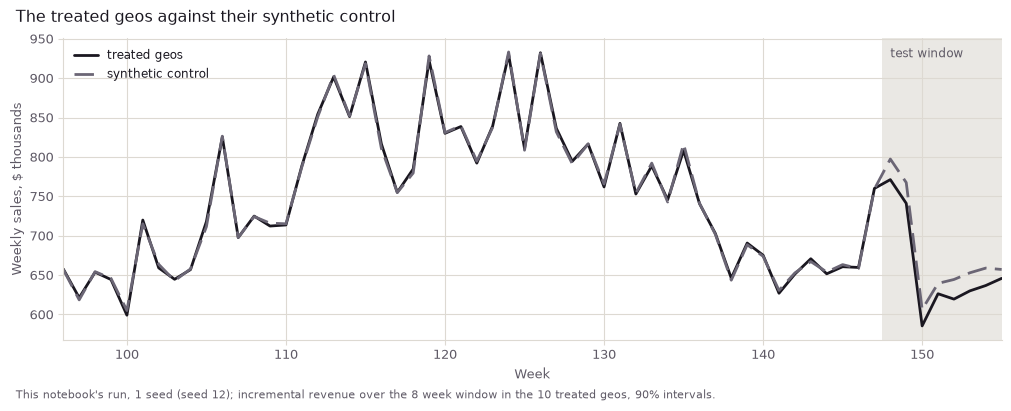

In [5]:
first_week = registered.start_week - registered.pre_period_weeks
recent = geo_after.filter(pl.col("week") >= first_week)
treated_series = (
    recent.filter(pl.col("geo").is_in(list(registered.treated_geos))).group_by("week").agg(pl.col("sales").sum()).sort("week")
)
controls_wide = recent.filter(pl.col("geo").is_in(list(registered.control_geos))).pivot(on="geo", index="week", values="sales").sort("week")
synthetic = sum(controls_wide[str(g)].to_numpy() * w for g, w in sc.weights.items())
weeks = treated_series["week"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 3.8), layout="constrained")
ax.axvspan(registered.start_week - 0.5, registered.end_week + 0.5, color=HAIRLINE, alpha=0.6, lw=0)
ax.text(registered.start_week, 0.97, "test window", transform=ax.get_xaxis_transform(), va="top", fontsize=8.5, color=INK2)
ax.plot(weeks, treated_series["sales"].to_numpy() / 1e3, color=INK, label="treated geos")
ax.plot(weeks, synthetic / 1e3, color=CONTROL, ls=(0, (7, 3)), label="synthetic control")
ax.set_xlim(weeks[0], weeks[-1])
ax.set_xlabel("Week")
ax.set_ylabel("Weekly sales, $ thousands")
ax.legend(loc="upper left")
finish(fig, "The treated geos against their synthetic control", TEST)

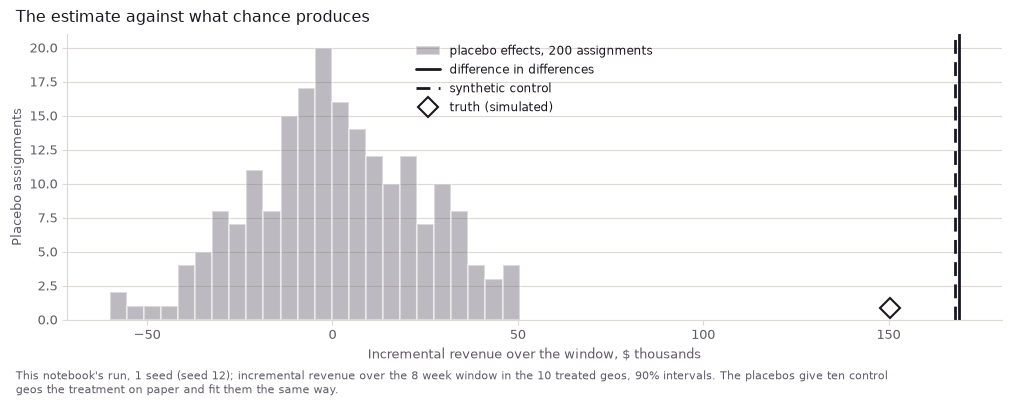

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.6), layout="constrained")
ax.hist(np.array(sc.placebo_effects) / 1e3, bins=24, color=CONTROL, alpha=0.45, edgecolor=RAISED, linewidth=1.5, label=f"placebo effects, {sc.placebo_permutations} assignments")
ax.axvline(did.incremental_revenue / 1e3, color=INK, lw=2, label="difference in differences")
ax.axvline(sc.incremental_revenue / 1e3, color=INK, lw=2, ls=(0, (5, 3)), label="synthetic control")
ax.plot(truth_lift / 1e3, 0.04, "D", ms=10, mfc=RAISED, mec=INK, mew=1.5, transform=ax.get_xaxis_transform(), clip_on=False, label="truth (simulated)")
ax.set_xlabel("Incremental revenue over the window, $ thousands")
ax.set_ylabel("Placebo assignments")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center")
finish(fig, "The estimate against what chance produces", TEST + " The placebos give ten control geos the treatment on paper and fit them the same way.")

Both methods find the holdout clearly: the estimates sit far outside anything the placebo assignments produce. Both also land above the truth, and the difference in differences interval stops just short of it. An experiment is a measurement with its own error, not the truth, and the calibration in section 6 inherits that error.

## 4. The dead end, kept: the synthetic control that put all its weight on one geo

The first version of this analysis ended with a synthetic control that put all its weight on one geo. I rebuild that failure in its plainest form, the way many geo tests are still read: take the control geo whose sales tracked the treated group most closely before the test, a matched market, and scale it to the treated group. Its pre period correlation is excellent, and it is the wrong control.

The fit uses the module's own step (`_synthetic_effect`, the non negative least squares the final fit uses) on a donor pool of one: the best matching control geo. Then I ask it the question the placebo test asks of the final fit: what does this procedure produce when nothing happened? I draw 200 groups of ten control geos that were never treated, give each group its own matched market from the remaining controls in the same way, and record the gap over the window.

In [7]:
from marginal_core.seeds import rng
from marginal_experiments.geo_lift import _matrix, _synthetic_effect, _window_frame

frame = _window_frame(geo_after, registered)
fit_weeks, treated_matrix = _matrix(frame, list(registered.treated_geos))
controls = list(registered.control_geos)
_, control_matrix = _matrix(frame, controls)
treated_sum = treated_matrix.sum(axis=1)
pre_weeks = fit_weeks < registered.start_week
sign = -1.0 if registered.spend_change < 0 else 1.0  # a holdout's lift is the size of the negative gap, as in the module


def pre_correlations(target, pool):
    return np.array([np.corrcoef(target[pre_weeks], pool[pre_weeks, i])[0, 1] for i in range(pool.shape[1])])


def matched_market(target, pool):
    # The first version's control: the one geo that tracked the target best before the test, scaled to it.
    best = int(np.argmax(pre_correlations(target, pool)))
    gap, weight, rmse = _synthetic_effect(fit_weeks, target, pool[:, [best]], registered)
    return best, sign * gap, float(weight[0]), rmse


best, matched_effect, matched_weight, matched_rmse = matched_market(treated_sum, control_matrix)
draw = rng(SEED, "matched market placebo", registered.plan_hash)
matched_placebo = []
for _ in range(registered.placebo_permutations):
    chosen = np.sort(draw.choice(len(controls), size=len(registered.treated_geos), replace=False))
    _, effect, _, _ = matched_market(control_matrix[:, chosen].sum(axis=1), np.delete(control_matrix, chosen, axis=1))
    matched_placebo.append(effect)
matched_placebo = np.array(matched_placebo)
alpha = (1.0 - registered.interval_level) / 2.0
matched_lower = matched_effect + float(np.quantile(matched_placebo, alpha))
matched_upper = matched_effect + float(np.quantile(matched_placebo, 1.0 - alpha))
full_placebo = np.array(sc.placebo_effects)

DEAD = run(1, f" (seed {SEED}); {registered.placebo_permutations} placebo groups for each procedure, {registered.interval_level:.0%} intervals from the placebo distribution")
show(
    ["Procedure", "Largest weight", "Pre period error a week", "Estimate", "Lower", "Upper", "Placebo spread (sd)", "Covers the truth"],
    [
        [
            f"Full donor pool, {len(controls)} geos (final)",
            f"{sc.largest_weight:.0%}",
            usd(sc.pre_period_rmse),
            usd(sc.incremental_revenue),
            usd(sc.lower),
            usd(sc.upper),
            usd(full_placebo.std()),
            "yes" if sc.lower <= truth_lift <= sc.upper else "no",
        ],
        [
            f"Matched market, geo {controls[best]} (the dead end)",
            "100%",
            usd(matched_rmse),
            usd(matched_effect),
            usd(matched_lower),
            usd(matched_upper),
            usd(matched_placebo.std()),
            "yes" if matched_lower <= truth_lift <= matched_upper else "no",
        ],
    ],
    DEAD + f" Truth (simulated) {usd(truth_lift)}.",
)
print()
correlations = pre_correlations(treated_sum, control_matrix)
alternatives = []
for i in np.argsort(-correlations)[:5]:
    gap, _, _ = _synthetic_effect(fit_weeks, treated_sum, control_matrix[:, [i]], registered)
    alternatives.append([f"geo {controls[i]}", f"{correlations[i]:.4f}", usd(sign * gap)])
show(["The five best matches", "Pre period correlation", "Estimate if used alone"], alternatives, run(1, f" (seed {SEED})") + f" Truth (simulated) {usd(truth_lift)}.")

Procedure                             Largest weight  Pre period error a week  Estimate     Lower     Upper  Placebo spread (sd)  Covers the truth
------------------------------------  --------------  -----------------------  --------  --------  --------  -------------------  ----------------
Full donor pool, 30 geos (final)                 16%                   $3,052  $167,952  $131,871  $206,046              $22,691               yes
Matched market, geo 2 (the dead end)            100%                  $10,455   $84,929   -$7,769  $111,171              $33,229                no
This notebook's run, 1 seed (seed 12); 200 placebo groups for each procedure, 90% intervals from the placebo distribution. Truth (simulated) $150,478.

The five best matches  Pre period correlation  Estimate if used alone
---------------------  ----------------------  ----------------------
geo 2                                  0.9932                 $84,929
geo 25                                 0.9924     

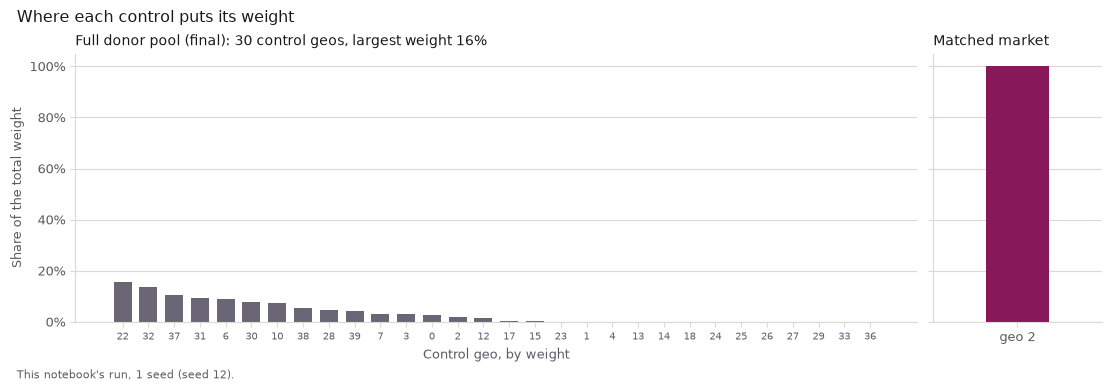

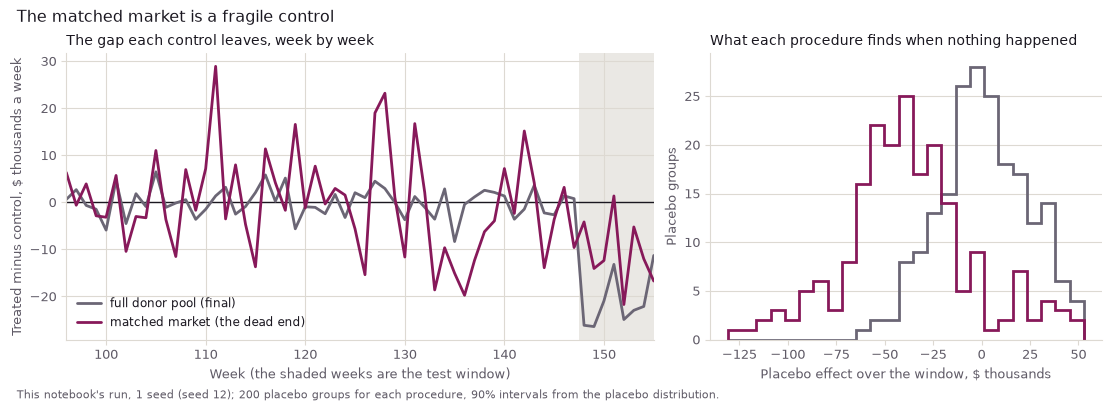

In [8]:
matched_color, full_color = SEQ[3], CONTROL
shares = pl.DataFrame({"geo": list(sc.weights), "weight": list(sc.weights.values())}).with_columns(
    (pl.col("weight") / pl.col("weight").sum()).alias("share")
).sort("share", descending=True)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6), width_ratios=[5, 1], sharey=True, layout="constrained")
left.bar(range(shares.height), shares["share"].to_numpy(), width=0.7, color=full_color)
left.set_xticks(range(shares.height), [str(g) for g in shares["geo"].to_list()], fontsize=7.5)
left.set_title(f"Full donor pool (final): {len(controls)} control geos, largest weight {sc.largest_weight:.0%}")
left.set_xlabel("Control geo, by weight")
left.set_ylabel("Share of the total weight")
left.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
left.grid(axis="x", visible=False)
right.bar([0], [1.0], width=0.6, color=matched_color)
right.set_xticks([0], [f"geo {controls[best]}"])
right.set_xlim(-0.8, 0.8)
right.set_title("Matched market")
right.grid(axis="x", visible=False)
finish(fig, "Where each control puts its weight", run(1, f" (seed {SEED})"))

synthetic_full = control_matrix @ np.array([sc.weights[g] for g in controls])
synthetic_matched = control_matrix[:, best] * matched_weight
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8), width_ratios=[3, 2], layout="constrained")
left.axvspan(registered.start_week - 0.5, registered.end_week + 0.5, color=HAIRLINE, alpha=0.6, lw=0)
left.axhline(0.0, color=INK, lw=1)
left.plot(fit_weeks, (treated_sum - synthetic_full) / 1e3, color=full_color, label="full donor pool (final)")
left.plot(fit_weeks, (treated_sum - synthetic_matched) / 1e3, color=matched_color, label="matched market (the dead end)")
left.set_xlim(fit_weeks[0], fit_weeks[-1])
left.set_xlabel("Week (the shaded weeks are the test window)")
left.set_ylabel("Treated minus control, $ thousands a week")
left.set_title("The gap each control leaves, week by week")
left.legend(loc="lower left")
bins = np.linspace(min(full_placebo.min(), matched_placebo.min()), max(full_placebo.max(), matched_placebo.max()), 26) / 1e3
right.hist(full_placebo / 1e3, bins=bins, histtype="step", lw=2, color=full_color, label="full donor pool (final)")
right.hist(matched_placebo / 1e3, bins=bins, histtype="step", lw=2, color=matched_color, label="matched market (the dead end)")
right.set_xlabel("Placebo effect over the window, $ thousands")
right.set_ylabel("Placebo groups")
right.set_title("What each procedure finds when nothing happened")
right.grid(axis="x", visible=False)
finish(fig, "The matched market is a fragile control", DEAD)

The matched market fits the pre period worse than the full pool, and its placebo distribution is wider and sits well left of zero: on groups that were never treated, it tends to report a negative effect of tens of thousands of dollars. Its estimate lands well below the truth, and its interval runs from below zero to well short of the truth, so read this way the test would not even have shown with confidence that the holdout cost anything. The table of the five best matches is the reason in one look. Five control geos track the treated group almost equally well before the test, and each of them, used alone, gives a different answer. A control that is one geo carries that geo's noise into the window, and the estimate follows whichever geo the ranking happened to favour.

The final fit keeps the full donor pool, weights the geos by non negative least squares on the pre period, reports the largest weight so that a fit leaning on one geo shows it, and counts its placebo permutations; a test in the suite fails if the loop did not run them all. Its interval comes from the placebo distribution around the estimate, so a fragile control shows up as a wide interval rather than hiding behind a good pre period correlation.

## 5. Power by simulation

A design needs a stated power before its data exists: the share of simulated tests, on markets like this one, whose difference in differences interval excludes zero. `power_curve` draws a fresh market for each simulation, runs a shorter or smaller version of the test on it and records whether the interval excludes zero, along with the lift the test truly removed. I run three effect sizes (all of the channel's spend removed, half of it and a quarter of it) and two lengths (four and eight weeks), twenty markets per cell. The published power study used sixty.

6 cells of 20 simulated markets in 3 seconds.
Spend removed  Test length (weeks)  Power  Mean true lift
-------------  -------------------  -----  --------------
100%                             4   100%         $78,030
100%                             8   100%        $156,473
50%                              4   100%         $42,103
50%                              8   100%         $89,143
25%                              4    55%         $18,984
25%                              8    75%         $40,363
This notebook's run, 20 seeds per cell (seeds 5000 to 5019).
At the registered design, all of the spend removed for 8 weeks: power 100%. This notebook's run, 20 seeds per cell (seeds 5000 to 5019).
Published power at the true effect: 100%  [Source: simulated, model did, 10 treated geos of 40, 8 weeks, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
Published simulations per cell: 60  [Source: simulated, model did, 10 treated geos of 40, 8 weeks, condition rho 0.6, feedback 

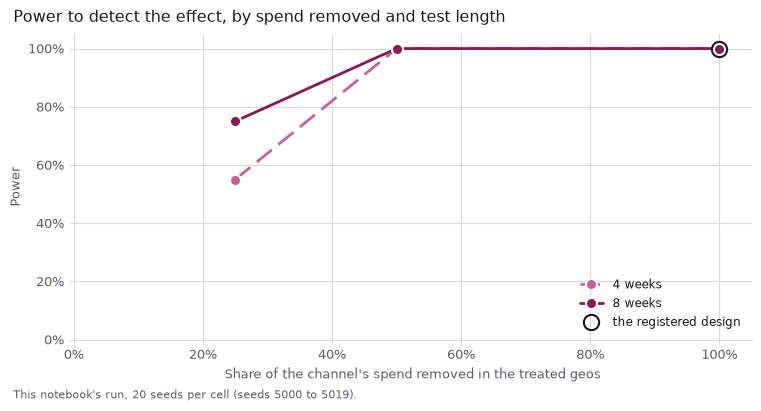

In [9]:
from marginal_experiments import power_curve

started = time.perf_counter()
cells = power_curve(base, registered, spend_multipliers=(0.0, 0.5, 0.75), window_lengths=(4, 8), simulations=20)
print(f"{len(cells)} cells of {cells[0].simulations} simulated markets in {time.perf_counter() - started:.0f} seconds.")
POWER = run(cells[0].simulations, " per cell (seeds 5000 to 5019)")
show(
    ["Spend removed", "Test length (weeks)", "Power", "Mean true lift"],
    [[f"{1.0 - c.spend_multiplier:.0%}", c.window_weeks, f"{c.power:.0%}", usd(c.mean_true_lift)] for c in cells],
    POWER,
)
at_design = next(c for c in cells if c.spend_multiplier == 1.0 + registered.spend_change and c.window_weeks == registered.window_weeks)
print(f"At the registered design, all of the spend removed for {registered.window_weeks} weeks: power {at_design.power:.0%}. {POWER}")
print("Published power at the true effect:", published("geo.power_at_true_effect"))
print("Published simulations per cell:", published("geo.power_simulations"))

fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
for weeks_long, color, dash in ((4, SEQ[1], (0, (7, 3))), (8, SEQ[3], "-")):
    part = sorted((1.0 - c.spend_multiplier, c.power) for c in cells if c.window_weeks == weeks_long)
    ax.plot([p[0] for p in part], [p[1] for p in part], color=color, ls=dash, marker="o", ms=8, mec=RAISED, mew=1.5, label=f"{weeks_long} weeks")
ax.plot(1.0, at_design.power, "o", ms=11, mfc="none", mec=INK, mew=1.5, label="the registered design")
ax.set_xlim(0.0, 1.05)
ax.set_ylim(0.0, 1.05)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Share of the channel's spend removed in the treated geos")
ax.set_ylabel("Power")
ax.legend(loc="lower right")
finish(fig, "Power to detect the effect, by spend removed and test length", POWER)

The registered test is a large intervention: all of the channel's spend, eight weeks, a quarter of the market. At that size power sits at the ceiling in this run and in the published study. The curve earns its place at the small end, where a test that removes a quarter of the spend could easily miss an effect that is there, and a longer window helps. With twenty markets a cell, each power figure moves in steps of five points, which is why the published study used sixty.

## 6. Calibration: the experiment constrains the model

The posted result goes into the model as a constraint. For `own` it is a pseudo observation: the lift the model implies for the test's geos and weeks is pulled toward the experiment's estimate, weighted by the experiment's precision, and the transform search runs again with that row in place. I fit `own` on the market as it ran, test weeks included, because that is the panel an analyst has, and calibrate it with the difference in differences result. The truth beside it is read from the same 52 weeks of the same market.

In [10]:
from marginal_evaluation import observed
from marginal_mmm import LiftResult, MMMSpec, fit
from marginal_sim import national_truth_table

own_spec = MMMSpec(backend="own", seed=SEED)
panel = observed(national_after)
started = time.perf_counter()
model = fit(panel, own_spec)
geo_weights = geo_after.filter(pl.col("week") == 0).select("geo", "geo_weight")
lift = LiftResult(
    channel=registered.channel,
    window_start_week=registered.start_week,
    window_end_week=registered.end_week,
    geo_share=float(geo_weights.filter(pl.col("geo").is_in(list(registered.treated_geos)))["geo_weight"].sum()),
    incremental_revenue=did.incremental_revenue,
    standard_error=did.standard_error,
    spend_change=registered.spend_change,
    experiment_id="notebook 02",
    plan_hash=registered.plan_hash,
)
calibrated = model.calibrate([lift])
CAL = run(1, f" (seed {SEED}); own fit on the market as it ran, test weeks included")
print(f"Fit and calibrated in {time.perf_counter() - started:.0f} seconds; the treated geos hold {lift.geo_share:.1%} of the market. {CAL}")

tested_truth = national_truth_table(national_after, market_after).filter(pl.col("channel") == lift.channel).row(0, named=True)
before = next(e for e in model.intervals() if e.channel == lift.channel)
after = next(e for e in calibrated.intervals() if e.channel == lift.channel)
covers = [e.roas_lower <= tested_truth["roas_true"] <= e.roas_upper for e in (before, after)]
show(
    [CHANNEL_LABELS[lift.channel], "Before", "After", "Truth (simulated)"],
    [
        ["Return on ad spend", f"{before.roas:.2f}", f"{after.roas:.2f}", f"{tested_truth['roas_true']:.2f}"],
        [f"Interval lower ({own_spec.level:.0%})", f"{before.roas_lower:.2f}", f"{after.roas_lower:.2f}", ""],
        ["Interval upper", f"{before.roas_upper:.2f}", f"{after.roas_upper:.2f}", ""],
        ["Covers the truth", *("yes" if c else "no" for c in covers), ""],
        ["Marginal return", f"{before.marginal_return:.2f}", f"{after.marginal_return:.2f}", f"{tested_truth['marginal_return_true']:.2f}"],
    ],
    CAL,
)
print()
implied = {"before": model.implied_lift(lift), "after": calibrated.implied_lift(lift)}
show(
    ["Lift in the treated geos over the window", "Dollars"],
    [
        ["Implied by the model before", usd(implied["before"])],
        ["Found by the experiment", f"{usd(did.incremental_revenue)} ({usd(did.lower)} to {usd(did.upper)})"],
        ["Implied by the model after", usd(implied["after"])],
        ["True (simulated)", usd(truth_lift)],
    ],
    CAL,
)

Fit and calibrated in 26 seconds; the treated geos hold 23.2% of the market. This notebook's run, 1 seed (seed 12); own fit on the market as it ran, test weeks included.
Display and retargeting  Before  After  Truth (simulated)
-----------------------  ------  -----  -----------------
Return on ad spend         1.70   1.48               1.22
Interval lower (90%)       1.21   1.44                   
Interval upper             2.03   1.50                   
Covers the truth            yes     no                   
Marginal return            0.77   0.53               0.73
This notebook's run, 1 seed (seed 12); own fit on the market as it ran, test weeks included.

Lift in the treated geos over the window                          Dollars
----------------------------------------  -------------------------------
Implied by the model before                                      $187,960
Found by the experiment                   $169,063 ($151,588 to $186,538)
Implied by the model after        

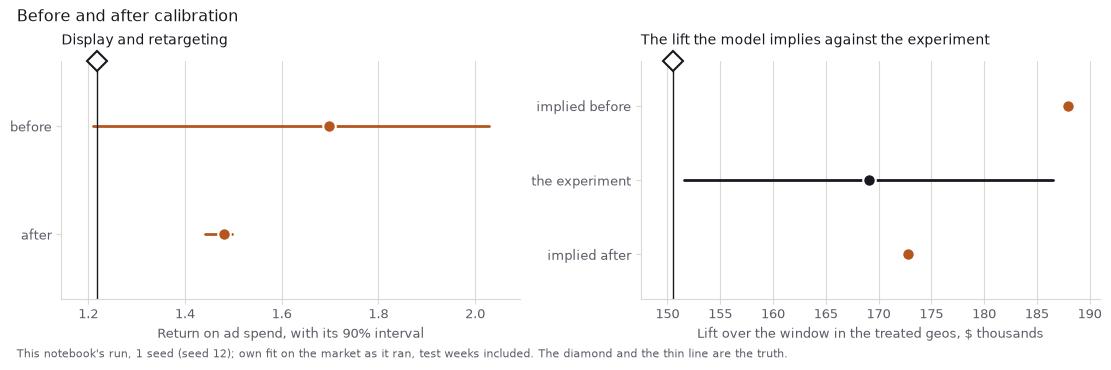

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")
color = COLOR[lift.channel]
for y, (name, e) in zip((1, 0), (("before", before), ("after", after))):
    left.plot([e.roas_lower, e.roas_upper], [y, y], color=color, lw=2)
    left.plot(e.roas, y, "o", ms=9, color=color, mec=RAISED, mew=1.5)
left.axvline(tested_truth["roas_true"], color=INK, lw=1)
left.plot(tested_truth["roas_true"], 1.0, "D", ms=10, mfc=RAISED, mec=INK, mew=1.5, transform=left.get_xaxis_transform(), clip_on=False)
left.margins(x=0.08)
left.set_yticks([1, 0], ["before", "after"])
left.set_ylim(-0.6, 1.6)
left.grid(axis="y", visible=False)
left.set_xlabel(f"Return on ad spend, with its {own_spec.level:.0%} interval")
left.set_title(CHANNEL_LABELS[lift.channel], pad=12)

right.plot([did.lower / 1e3, did.upper / 1e3], [1, 1], color=INK, lw=2)
right.plot(did.incremental_revenue / 1e3, 1, "o", ms=9, color=INK, mec=RAISED, mew=1.5)
for y, key in ((2, "before"), (0, "after")):
    right.plot(implied[key] / 1e3, y, "o", ms=9, color=color, mec=RAISED, mew=1.5)
right.axvline(truth_lift / 1e3, color=INK, lw=1)
right.plot(truth_lift / 1e3, 1.0, "D", ms=10, mfc=RAISED, mec=INK, mew=1.5, transform=right.get_xaxis_transform(), clip_on=False)
right.margins(x=0.08)
right.set_yticks([2, 1, 0], ["implied before", "the experiment", "implied after"])
right.set_ylim(-0.6, 2.6)
right.grid(axis="y", visible=False)
right.set_xlabel("Lift over the window in the treated geos, $ thousands")
right.set_title("The lift the model implies against the experiment", pad=12)
finish(fig, "Before and after calibration", CAL + " The diamond and the thin line are the truth.")

Calibration did its job on the average. The lift the model implies moved from just above the experiment's interval into it, and the return moved toward the truth. Two things did not improve. The interval after calibration is narrow and no longer holds the truth, because the experiment it was pulled onto sits above the truth. And the marginal return, the number the optimizer uses, moved away from the truth: an experiment pins down how much the channel added over the window, not the slope of its curve at today's spend.

The weight the experiment carries has its own test. If the calibrated fit reproduced the experiment exactly, the weight, not the data, would have chosen the fit. `weight_interior_test` refits with the weight halved, as stated and doubled: the weight is an operating point when the gap between the implied and the found lift shrinks as the weight grows and is not zero at the stated weight. Three more full fits, so this cell takes a while.

In [12]:
from marginal_calibrate import weight_interior_test

started = time.perf_counter()
weight_test = weight_interior_test(panel, own_spec, lift)
print(f"Three calibrated fits in {time.perf_counter() - started:.0f} seconds.")
show(
    ["Weight on the experiment", "Implied lift minus found"],
    [
        ["half the stated weight", usd(weight_test.residual_half)],
        ["the stated weight", usd(weight_test.residual_one)],
        ["double the stated weight", usd(weight_test.residual_double)],
    ],
    CAL,
)
print(f"Verdict: {'interior' if weight_test.interior else 'degenerate'}; {weight_test.reason}. {CAL}")
print("Published verdict:", published("calibrate.weight.interior"))

Three calibrated fits in 39 seconds.
Weight on the experiment  Implied lift minus found
------------------------  ------------------------
half the stated weight                      $7,166
the stated weight                           $3,712
double the stated weight                    $2,218
This notebook's run, 1 seed (seed 12); own fit on the market as it ran, test weeks included.
Verdict: interior; the residual against the experiment shrinks as the weight grows and is not zero at the stated weight. This notebook's run, 1 seed (seed 12); own fit on the market as it ran, test weeks included.
Published verdict: interior  [Source: simulated, model own, demonstration brand, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]


The published calibration ran the same loop on the demonstration brand for both backends, and then recalibrated every seed of the demonstration condition to see what the experiment does to the recovery error. I read those figures from the manifest.

In [13]:
print("The posted experiment:", published("calibrate.experiment_lift"))
print("The true lift:", published("calibrate.truth_lift"))
for backend in ("own", "bayes"):
    print()
    print(f"Published calibration of {backend}, {manifest.text('calibrate.channel').lower()} on the demonstration brand:")
    for key, what in [
        ("roas_before", "return before"),
        ("roas_before_lower", "  interval lower"),
        ("roas_before_upper", "  interval upper"),
        ("covers_before", "  covers the truth"),
        ("roas_after", "return after"),
        ("roas_after_lower", "  interval lower"),
        ("roas_after_upper", "  interval upper"),
        ("covers_after", "  covers the truth"),
        ("roas_true", "truth (simulated)"),
        ("marginal_before", "marginal return before"),
        ("marginal_after", "marginal return after"),
        ("marginal_true", "true marginal return"),
        ("implied_before", "lift implied before"),
        ("implied_after", "lift implied after"),
        ("recovery.tested_error_before", "median absolute error on the tested channel across seeds, before"),
        ("recovery.tested_error_after", "  after"),
        ("recovery.error_before", "median absolute error on every channel across seeds, before"),
        ("recovery.error_after", "  after"),
        ("recovery.coverage_before", "interval coverage across seeds, before"),
        ("recovery.coverage_after", "  after"),
    ]:
        print(f"  {what}: {published(f'calibrate.{backend}.{key}')}")

The posted experiment: $169,063  [Source: simulated, the posted lift result, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
The true lift: $150,478  [Source: simulated, the posted lift result, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]

Published calibration of own, display and retargeting on the demonstration brand:
  return before: 1.62  [Source: simulated, model own, demonstration brand, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
    interval lower: 1.18  [Source: simulated, model own, demonstration brand, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
    interval upper: 1.92  [Source: simulated, model own, demonstration brand, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
    covers the truth: yes  [Source: simulated, model own, demonstration brand, condition rho 0.6, feedback on, seed 12, as of 2026-09-27.]
  return after: 1.31  [Source: simulated, model own, demonstration brand, condition rho 0.6, feedback

What the published figures mean. On the demonstration brand, calibration moves the display and retargeting return toward the truth for both backends, and both end with an interval that no longer covers the truth. For `bayes` the change is starkest: its interval was wide enough to hold the truth before and is narrow and off it after. That is not a contradiction. Calibration treats the experiment as a measurement with the standard error it reported, and the experiment itself landed above the truth with an interval that just misses it. A model pulled onto a slightly wrong measurement becomes more certain and a little wrong, which is what this notebook's run shows too. The marginal return tells the same story as here for `own`, moving away from the truth; for `bayes`, which started far above it, it moved toward it.

Across the seeds of the demonstration condition, calibration cuts the error on the tested channel for both backends and trims it across all channels, and it does not make `own`'s intervals cover the truth more often. I read that as the right use of an experiment: it pulls the tested channel's contribution toward what was measured, and the interval after calibration is the model's statement of its own uncertainty, not the world's.